## Resample channels to a common range geometry

```{important}
This notebook uses development-version functionality that is not yet available in the latest released version of `echopype`.

Users need to install `echopype` from source to reproduce the examples shown here.
```

### Introduction

Different frequencies may not share the same vertical sampling resolution or the same maximum range.

When comparing channels directly, it is often useful to express them on a common range geometry.

This notebook demonstrates two approaches:

1. Resample to the exact geometry of the 200 kHz channel.
2. Resample to a custom grid using the 200 kHz spacing while extending the range support.

The examples below also illustrate how these choices affect the final data geometry.

In [1]:
import echopype as ep
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from echopype.commongrid import resample_to_geometry

#### Load an EK80 dataset

We first load a multi-frequency EK80 dataset and compute calibrated volume backscattering strength (`Sv`).

Depth is then added to the dataset to simplify comparisons between channels with different acquisition geometries.

In [2]:
raw_path = (
    "s3://noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH2306/EK80/"
    "Hake-D20230811-T165727.raw"
)

ed = ep.open_raw(
    raw_path,
    sonar_model="EK80",
    storage_options={"anon": True},
)

ds_Sv = ep.calibrate.compute_Sv(
    echodata=ed,
    waveform_mode="CW",
    encode_mode="power",
)

ds_Sv = ep.consolidate.add_depth(ds_Sv)
ds_Sv

<xarray.Dataset> Size: 926MB
Dimensions:                        (channel: 5, ping_time: 213,
                                    range_sample: 36198, filenames: 1)
Coordinates:
  * channel                        (channel) object 40B 'WBT 400140-15 ES120-...
  * ping_time                      (ping_time) datetime64[ns] 2kB 2023-08-11T...
  * range_sample                   (range_sample) int64 290kB 0 1 ... 36197
  * filenames                      (filenames) int64 8B 0
Data variables: (12/26)
    Sv                             (channel, ping_time, range_sample) float64 308MB ...
    echo_range                     (channel, ping_time, range_sample) float64 308MB ...
    tau_effective                  (channel) float64 40B 0.0009239 ... 0.0009306
    frequency_nominal              (channel) float64 40B 1.2e+05 ... 2e+05
    sound_speed                    float64 8B 1.48e+03
    sound_absorption               (channel) float64 40B 0.03281 ... 0.0463
    ...                             ...
    impedance_transducer           (channel) float64 40B 75.0 75.0 ... 75.0 75.0
    impedance_transceiver          (channel) int64 40B 5400 5400 5400 5400 5400
    receiver_sampling_frequency    (channel) float64 40B 1.5e+06 ... 1.5e+06
    source_filenames               (filenames) <U82 328B 's3://noaa-wcsd-pds/...
    water_level                    float64 8B 0.0
    depth                          (channel, ping_time, range_sample) float64 308MB ...
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-11T02:14:04+00:00
    processing_function:          calibrate.compute_Sv

#### Helper functions

The function below is used throughout the notebook to compare channel geometries before and after resampling.

In [3]:
def plot_depth_and_range_sample(ds_plot, title, max_depth=None, max_range_sample=None):
    channels = ds_plot.channel.values
    n_channels = len(channels)

    if max_depth is None:
        max_depth = float(ds_plot["depth"].max(skipna=True).compute().values)

    if max_range_sample is None:
        max_range_sample = int(ds_plot["range_sample"].max().values)

    fig, axes = plt.subplots(
        2,
        n_channels,
        figsize=(3 * n_channels, 8),
        sharex=True,
        constrained_layout=True,
    )

    for i, ch in enumerate(channels):
        ds_ch = ds_plot.sel(channel=ch)

        Sv = ds_ch["Sv"].values.T
        time = ds_ch["ping_time"].values

        depth = ds_ch["depth"].values.T[:, 0]
        keep = np.isfinite(depth)

        im = axes[0, i].pcolormesh(
            time,
            depth[keep],
            Sv[keep, :],
            shading="auto",
            vmin=-80,
            vmax=-30,
            cmap="RdYlBu_r",
        )

        axes[0, i].set_title(f"{float(ds_ch.frequency_nominal) / 1000:.0f} kHz")
        axes[0, i].set_ylim(max_depth, 0)

        axes[1, i].pcolormesh(
            time,
            ds_ch["range_sample"].values,
            Sv,
            shading="auto",
            vmin=-80,
            vmax=-30,
            cmap="RdYlBu_r",
        )

        axes[1, i].set_ylim(max_range_sample, 0)

        if i == 0:
            axes[0, i].set_ylabel("Depth [m]")
            axes[1, i].set_ylabel("Range sample")

    for ax in axes.ravel():
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(title)
    fig.colorbar(im, ax=axes, label="Sv [dB]")

    plt.show()

#### Inspect the original geometries

The figure below shows each channel using its native acquisition geometry. Differences in sampling resolution and maximum range can be observed between frequencies. These differences motivate the resampling steps below.

The top row displays the data as a function of depth, while the bottom row shows the corresponding `range_sample` indices.

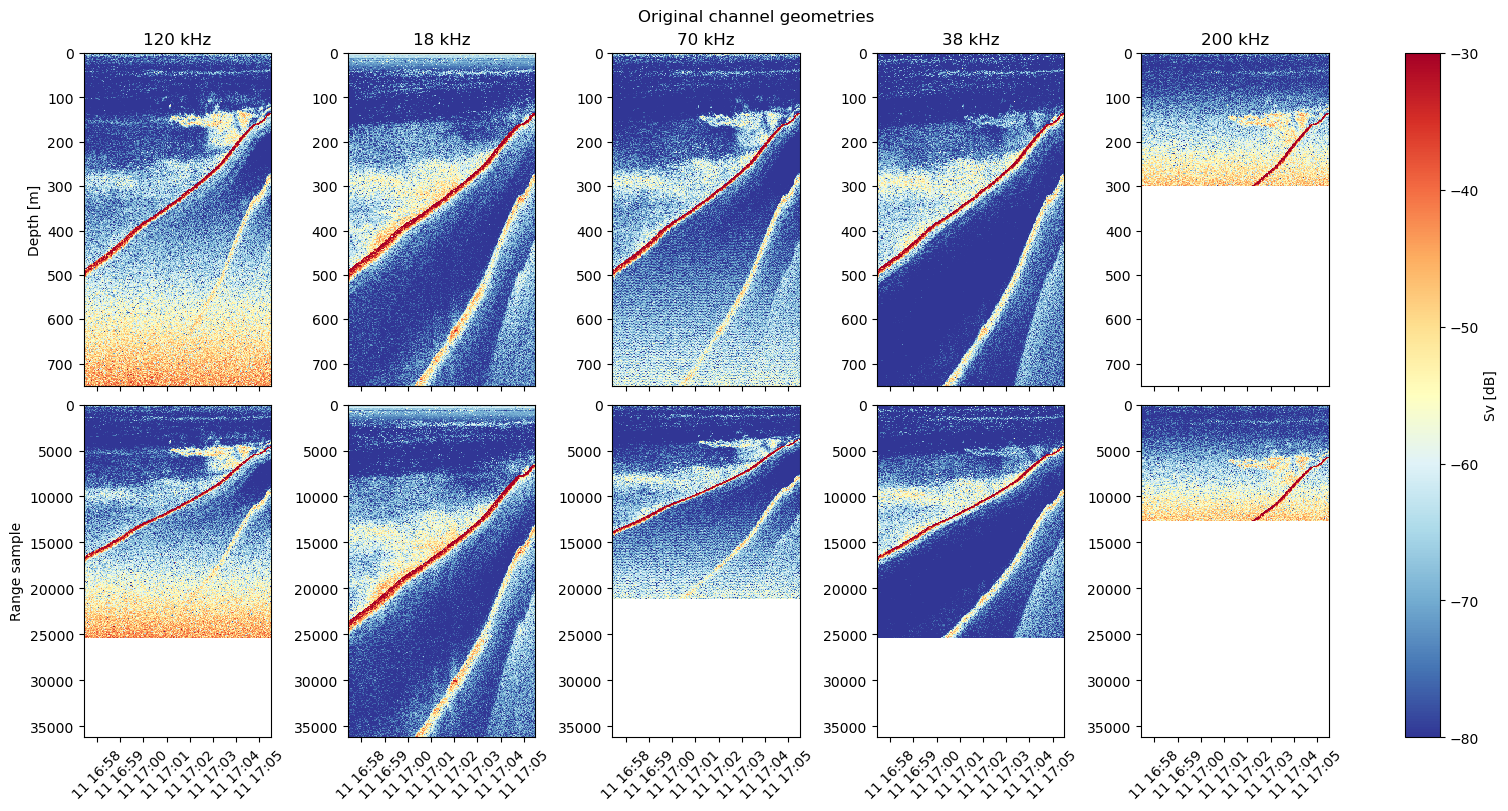

In [4]:
plot_depth_and_range_sample(
    ds_Sv,
    "Original channel geometries",
)

#### Select the reference channel

In this example, we use the 200 kHz channel as the reference geometry.

Its sampling resolution will be used in the following examples.

In [5]:
selected_channel = ds_Sv.channel.sel(
    channel=ds_Sv.frequency_nominal == 200000
).item()

selected_channel

'WBT 400145-15 ES200-7C_ES'

### Resample to the exact 200 kHz geometry

Here, all channels are resampled onto the exact geometry of the 200 kHz channel. This workflow is similar to Echoview's [Match Geometry](https://support.echoview.com/WebHelp/Reference/Algorithms/Operators/Match_geometry_algorithm.htm?rhhlterm=match%20matching&rhsearch=Match%20geomoetry) operator.

In [6]:
aligned_ds_200 = resample_to_geometry(
    ds_Sv.chunk({"channel": 1, "ping_time": 1000, "range_sample": -1}),
    target_variable="Sv",
    target_channel=selected_channel,
)

aligned_ds_200 = ep.consolidate.add_depth(aligned_ds_200)

aligned_ds_200

<xarray.Dataset> Size: 926MB
Dimensions:            (ping_time: 213, range_sample: 36198, channel: 5)
Coordinates:
  * ping_time          (ping_time) datetime64[ns] 2kB 2023-08-11T16:57:27.277...
  * range_sample       (range_sample) int64 290kB 0 1 2 3 ... 36195 36196 36197
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
Data variables:
    Sv                 (channel, ping_time, range_sample) float64 308MB dask.array<chunksize=(1, 213, 36198), meta=np.ndarray>
    echo_range         (channel, ping_time, range_sample) float64 308MB dask.array<chunksize=(5, 213, 36198), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(1,), meta=np.ndarray>
    water_level        float64 8B 0.0
    depth              (channel, ping_time, range_sample) float64 308MB dask.array<chunksize=(5, 213, 36198), meta=np.ndarray>
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-11T02:14:52+00:00
    processing_function:          commongrid.resample_to_geometry

#### Compare the resampled geometries

After resampling, all channels share the same sampling geometry.

Because the target geometry is defined by the 200 kHz channel, deeper portions of other channels may no longer be represented.

In [7]:
max_depth_strict = float(
    max(
        ds_Sv["depth"].max(skipna=True).compute().values,
        aligned_ds_200["depth"].max(skipna=True).compute().values,
    )
)

max_range_sample_strict = max(
    ds_Sv.sizes["range_sample"] - 1,
    aligned_ds_200.sizes["range_sample"] - 1,
)

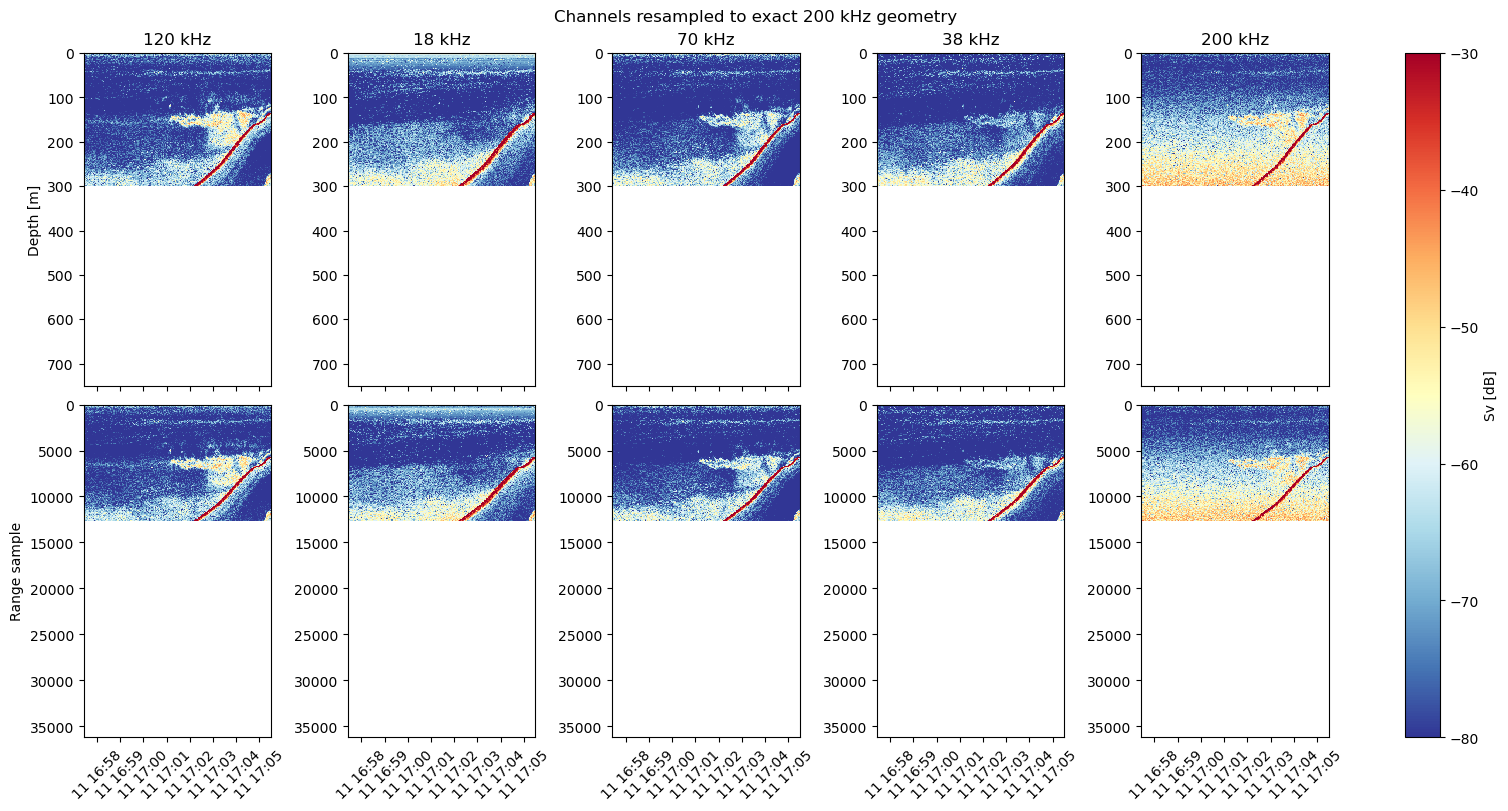

In [8]:
plot_depth_and_range_sample(
    aligned_ds_200,
    "Channels resampled to exact 200 kHz geometry",
    max_depth=max_depth_strict,
    max_range_sample=max_range_sample_strict,
)

#### Verify the resampling

We confirm that the output geometry matches the reference 200 kHz channel.

In [9]:
target_echo_range = ds_Sv["echo_range"].sel(channel=selected_channel)
output_echo_range = aligned_ds_200["echo_range"]

target_echo_range_broadcast = target_echo_range.broadcast_like(output_echo_range)
target_echo_range_broadcast = target_echo_range_broadcast.transpose(*output_echo_range.dims)

np.testing.assert_allclose(
    output_echo_range.values,
    target_echo_range_broadcast.values,
    rtol=0,
    atol=1e-10,
    equal_nan=True,
)

print("Strict match-geometry check passed.")

Strict match-geometry check passed.


### Build a custom 200 kHz-spacing grid

The previous step matched the exact 200 kHz geometry, including its maximum range.

Here, we instead use only the 200 kHz sample spacing and create a custom grid that extends to the maximum range available across all channels. This keeps a common vertical resolution while avoiding truncation to the 200 kHz range extent.

In [10]:
target_200 = ds_Sv["echo_range"].sel(channel=selected_channel)

spacing_200 = float(
    target_200.diff("range_sample").mean(skipna=True).compute().values
)

max_range = float(
    ds_Sv["echo_range"].max(skipna=True).compute().values
)

target_range = np.arange(
    0,
    max_range + spacing_200,
    spacing_200,
)

print(f"200 kHz spacing: {spacing_200:.4f} m")
print(f"Maximum range across channels: {max_range:.2f} m")
print(f"Custom target grid length: {len(target_range)}")
print(f"Original range_sample length: {ds_Sv.sizes['range_sample']}")

200 kHz spacing: 0.0237 m
Maximum range across channels: 749.98 m
Custom target grid length: 31674
Original range_sample length: 36198


#### Verify the custom grid

Before resampling, we verify that the custom grid is regularly spaced and compatible with the existing `range_sample` dimension.

In [11]:
target_spacing = np.diff(target_range)

np.testing.assert_allclose(
    target_spacing,
    spacing_200,
    rtol=0,
    atol=1e-10,
)

if len(target_range) > ds_Sv.sizes["range_sample"]:
    raise ValueError(
        "The custom target grid is longer than the existing range_sample dimension. "
        "The current implementation requires the target grid to fit within the existing dimension."
    )

print("Custom grid spacing is continuous and matches the 200 kHz spacing.")
print("Custom grid fits within the existing range_sample dimension.")

Custom grid spacing is continuous and matches the 200 kHz spacing.
Custom grid fits within the existing range_sample dimension.


#### Create the target grid

The target grid must use the same `ping_time` and `range_sample` coordinates as the input dataset. We therefore pad unused range samples with `NaN`.

These padded values define empty parts of the grid; they do not create artificial acoustic data.

In [12]:
n_range_sample = ds_Sv.sizes["range_sample"]

target_range_padded = np.full(n_range_sample, np.nan)
target_range_padded[: len(target_range)] = target_range

target_grid = xr.DataArray(
    np.tile(target_range_padded, (ds_Sv.sizes["ping_time"], 1)),
    dims=("ping_time", "range_sample"),
    coords={
        "ping_time": ds_Sv["ping_time"],
        "range_sample": ds_Sv["range_sample"],
    },
    name="echo_range",
)

target_grid

<xarray.DataArray 'echo_range' (ping_time: 213, range_sample: 36198)> Size: 62MB
array([[0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan],
       [0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan],
       [0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan],
       ...,
       [0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan],
       [0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan],
       [0.        , 0.02367923, 0.04735847, ...,        nan,        nan,
               nan]], shape=(213, 36198))
Coordinates:
  * ping_time     (ping_time) datetime64[ns] 2kB 2023-08-11T16:57:27.277163 ....
  * range_sample  (range_sample) int64 290kB 0 1 2 3 ... 36194 36195 36196 36197

#### Resample to the custom grid

Channels are now projected onto the custom grid.

The output uses the 200 kHz spacing, but the grid extends to the maximum range available across all channels. Values remain finite only where each source channel overlaps the target grid.

In [13]:
aligned_ds_custom = resample_to_geometry(
    ds_Sv.chunk({"channel": 1, "ping_time": 1000, "range_sample": -1}),
    target_variable="Sv",
    target_grid=target_grid,
)

aligned_ds_custom = ep.consolidate.add_depth(aligned_ds_custom)

aligned_ds_custom

<xarray.Dataset> Size: 926MB
Dimensions:            (ping_time: 213, range_sample: 36198, channel: 5)
Coordinates:
  * ping_time          (ping_time) datetime64[ns] 2kB 2023-08-11T16:57:27.277...
  * range_sample       (range_sample) int64 290kB 0 1 2 3 ... 36195 36196 36197
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
Data variables:
    Sv                 (channel, ping_time, range_sample) float64 308MB dask.array<chunksize=(1, 213, 36198), meta=np.ndarray>
    echo_range         (channel, ping_time, range_sample) float64 308MB 0.0 ....
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(1,), meta=np.ndarray>
    water_level        float64 8B 0.0
    depth              (channel, ping_time, range_sample) float64 308MB 0.0 ....
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-11T02:15:35+00:00
    processing_function:          commongrid.resample_to_geometry

In [14]:
max_depth_custom = float(
    max(
        ds_Sv["depth"].max(skipna=True).compute().values,
        aligned_ds_custom["depth"].max(skipna=True).compute().values,
    )
)

max_range_sample_custom = max(
    ds_Sv.sizes["range_sample"] - 1,
    aligned_ds_custom.sizes["range_sample"] - 1,
)

#### Inspect the custom-grid result

The plot below shows the result of using a common 200 kHz spacing while preserving the larger range extent.

Empty regions correspond to parts of the target grid where no valid source data were available.

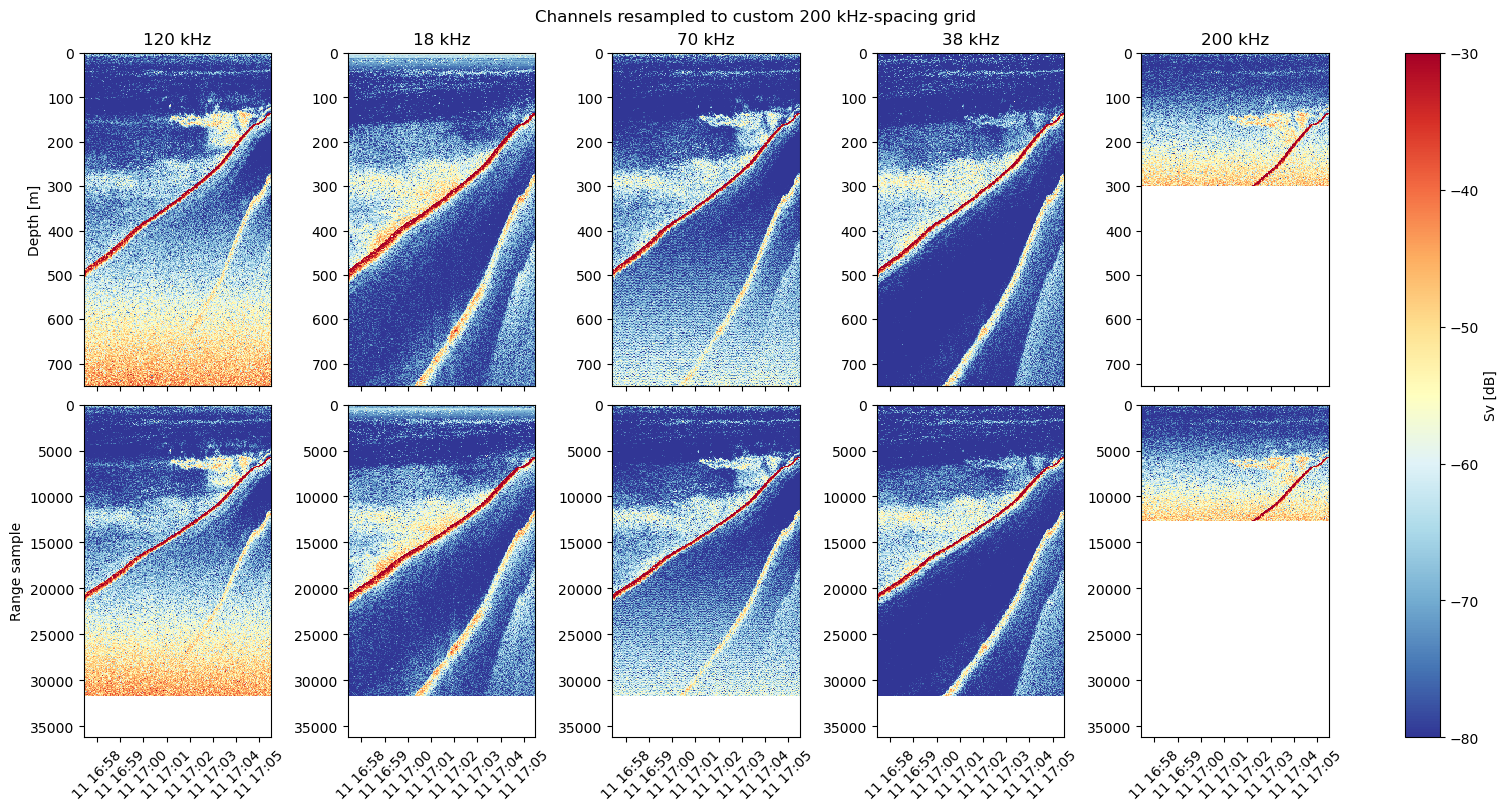

In [15]:
plot_depth_and_range_sample(
    aligned_ds_custom,
    "Channels resampled to custom 200 kHz-spacing grid",
    max_depth=max_depth_custom,
    max_range_sample=max_range_sample_custom,
)

### Compare finite data support

The table below compares the range extent of the original data, the strict 200 kHz match-geometry output, and the custom-grid output. The grid maximum describes the target geometry. The last finite Sv range describes where each channel still contains valid acoustic data.

In [16]:
rows = []

for ch in ds_Sv.channel.values:
    original = ds_Sv.sel(channel=ch)
    strict = aligned_ds_200.sel(channel=ch)
    custom = aligned_ds_custom.sel(channel=ch)

    rows.append(
        {
            "frequency_kHz": float(original.frequency_nominal) / 1000,
            "original_grid_max_m": float(
                original.echo_range.max(skipna=True).compute().values
            ),
            "strict_200_grid_max_m": float(
                strict.echo_range.max(skipna=True).compute().values
            ),
            "custom_grid_max_m": float(
                custom.echo_range.max(skipna=True).compute().values
            ),
            "original_last_finite_Sv_m": float(
                original.echo_range.where(original.Sv.notnull())
                .max(skipna=True)
                .compute()
                .values
            ),
            "strict_last_finite_Sv_m": float(
                strict.echo_range.where(strict.Sv.notnull())
                .max(skipna=True)
                .compute()
                .values
            ),
            "custom_last_finite_Sv_m": float(
                custom.echo_range.where(custom.Sv.notnull())
                .max(skipna=True)
                .compute()
                .values
            ),
        }
    )

pd.DataFrame(rows)

,frequency_kHz,original_grid_max_m,strict_200_grid_max_m,custom_grid_max_m,original_last_finite_Sv_m,strict_last_finite_Sv_m,custom_last_finite_Sv_m
0,120.0,749.980496,299.968519,749.992335,749.980496,299.968519,749.992335
1,18.0,749.977536,299.968519,749.992335,749.977536,299.968519,749.992335
2,70.0,749.980496,299.968519,749.992335,749.980496,299.968519,749.992335
3,38.0,749.980496,299.968519,749.992335,749.980496,299.968519,749.992335
4,200.0,299.968519,299.968519,749.992335,299.968519,299.968519,299.992198


#### Inspect geometry variables before and after resampling

The range spacing expected from the raw EK80 sampling is computed as `sound_speed * sample_interval / 2`. This value is not stored directly as a single variable in the calibrated `ds_Sv`; instead, it is reflected in the spacing of `echo_range`. Here we compare the expected spacing from the raw `EchoData`, the original calibrated geometry, and the resampled geometry.

In [17]:
def finite_spacing(da):
    values = da.values
    values = values[np.isfinite(values)]

    if values.size < 2:
        return np.nan

    return float(np.median(np.diff(values)))


rows = []

for ch in ds_Sv.channel.values:
    sample_interval = float(
        ed["Sonar/Beam_group1"]["sample_interval"]
        .sel(channel=ch)
        .median("ping_time")
        .values
    )

    sound_speed = float(ds_Sv["sound_speed"].values)
    expected_spacing = sound_speed * sample_interval / 2.0

    original_range = ds_Sv["echo_range"].sel(channel=ch).isel(ping_time=0)
    resampled_range = aligned_ds_200["echo_range"].sel(channel=ch).isel(ping_time=0)

    rows.append(
        {
            "frequency_kHz": float(ds_Sv["frequency_nominal"].sel(channel=ch)) / 1000,
            "sample_interval_s": sample_interval,
            "expected_spacing_m": expected_spacing,
            "original_spacing_m": finite_spacing(original_range),
            "resampled_spacing_m": finite_spacing(resampled_range),
            "original_max_range_m": float(original_range.max(skipna=True).values),
            "resampled_max_range_m": float(resampled_range.max(skipna=True).values),
        }
    )

geometry_spacing = pd.DataFrame(rows)
geometry_spacing

,frequency_kHz,sample_interval_s,expected_spacing_m,original_spacing_m,resampled_spacing_m,original_max_range_m,resampled_max_range_m
0,120.0,0.000040,0.029599,0.029599,0.023679,749.980496,299.968519
1,18.0,0.000028,0.020719,0.020719,0.023679,749.977536,299.968519
2,70.0,0.000048,0.035519,0.035519,0.023679,749.980496,299.968519
3,38.0,0.000040,0.029599,0.029599,0.023679,749.980496,299.968519
4,200.0,0.000032,0.023679,0.023679,0.023679,299.968519,299.968519


#### Inspect one ping profile before and after resampling

To visualize the effect of geometry matching more directly, we extract one ping around two-thirds of the echogram and compare the original and resampled samples as points. This makes the change in range/depth spacing visible without relying only on the echogram image.

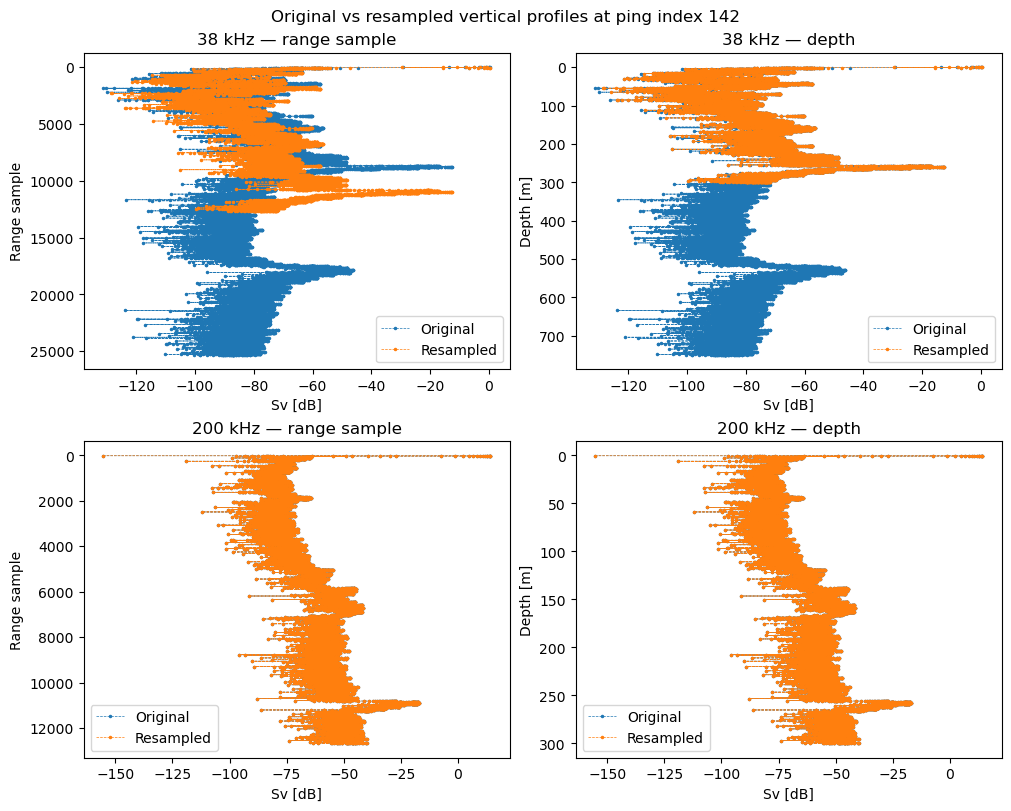

In [18]:
ping_index = int(ds_Sv.sizes["ping_time"] * 2 / 3)

frequencies_to_plot = [38_000, 200_000]

fig, axes = plt.subplots(
    len(frequencies_to_plot),
    2,
    figsize=(10, 4 * len(frequencies_to_plot)),
    sharey=False,
    constrained_layout=True,
)

for i, freq in enumerate(frequencies_to_plot):
    ch = ds_Sv.channel.sel(channel=ds_Sv.frequency_nominal == freq).item()

    original = ds_Sv.sel(channel=ch).isel(ping_time=ping_index)
    resampled = aligned_ds_200.sel(channel=ch).isel(ping_time=ping_index)

    original_valid = np.isfinite(original["Sv"].values)
    resampled_valid = np.isfinite(resampled["Sv"].values)

    axes[i, 0].plot(
        original["Sv"].values[original_valid],
        original["range_sample"].values[original_valid],
        ".--",
        linewidth=0.5,
        markersize=3,
        label="Original",
    )

    axes[i, 0].plot(
        resampled["Sv"].values[resampled_valid],
        resampled["range_sample"].values[resampled_valid],
        ".--",
        linewidth=0.5,
        markersize=3,
        label="Resampled",
    )

    axes[i, 0].set_title(f"{freq / 1000:.0f} kHz — range sample")
    axes[i, 0].set_xlabel("Sv [dB]")
    axes[i, 0].set_ylabel("Range sample")
    axes[i, 0].set_ylim(axes[i, 0].get_ylim()[::-1])
    axes[i, 0].legend()

    axes[i, 1].plot(
        original["Sv"].values[original_valid],
        original["depth"].values[original_valid],
        ".--",
        linewidth=0.5,
        markersize=3,
        label="Original",
    )

    axes[i, 1].plot(
        resampled["Sv"].values[resampled_valid],
        resampled["depth"].values[resampled_valid],
        ".--",
        linewidth=0.5,
        markersize=3,
        label="Resampled",
    )

    axes[i, 1].set_title(f"{freq / 1000:.0f} kHz — depth")
    axes[i, 1].set_xlabel("Sv [dB]")
    axes[i, 1].set_ylabel("Depth [m]")
    axes[i, 1].set_ylim(axes[i, 1].get_ylim()[::-1])
    axes[i, 1].legend()

fig.suptitle(f"Original vs resampled vertical profiles at ping index {ping_index}")
plt.show()

End of notebook.

In [19]:
import sys
import dask
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.version.split()[0])
print("echopype:", ep.__version__)
print("xarray:", xr.__version__)
print("dask:", dask.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.12.13
echopype: 0.11.2.dev22+gc1a2a5660
xarray: 2026.4.0
dask: 2026.3.0
numpy: 2.4.4
pandas: 3.0.2
matplotlib: 3.10.9
